# Random Forest — Proyecto de Minería de Datos (v2)
## Dataset: Matrimonios en Guatemala (`mat_full.csv`)

Este notebook expande el análisis original explorando **4 ejes de variación**:

1. **Codificación de etiquetas** — strings vs LabelEncoder vs OrdinalEncoder
2. **Estrategia de balanceo** — `class_weight`, SMOTE, Random Undersampling
3. **Bins alternativos** — diferentes umbrales para definir las clases
4. **Comparación explícita** — tablas y gráficas que cruzan todos los experimentos

Cada sección documenta **por qué** se hace el cambio y **qué efecto se espera**.

## 🔹 PASO 1: Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# SMOTE y undersampling requieren imbalanced-learn
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler
    IMBLEARN_OK = True
    print("imbalanced-learn disponible ✓")
except ImportError:
    IMBLEARN_OK = False
    print("imbalanced-learn NO disponible — instala con: pip install imbalanced-learn")
    print("Los experimentos de SMOTE/Undersampling serán omitidos.")

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print("Librerías cargadas ✓")

imbalanced-learn disponible ✓
Librerías cargadas ✓


## 🔹 PASO 2: Carga del Dataset

In [2]:
df = pd.read_csv('mat_full.csv')

for col in ['EDADHOM', 'EDADMUJ', 'AÑOREG']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Shape: {df.shape}")
df.head()

Shape: (752264, 15)


,AÑOREG,CLAUNI,DEPOCU,DEPREG,DIAOCU,EDADHOM,EDADMUJ,ESCHOM,ESCMUJ,MESOCU,MESREG,MUPOCU,MUPREG,NACHOM,NACMUJ
0,2011.0,Comunidad de gananciales,Guatemala,Guatemala,20.0,27.0,32.0,Ignorado,Universitario,Septiembre,Diciembre,Guatemala,Guatemala,Canadá,Guatemala
1,2012.0,Separación absoluta,Guatemala,Guatemala,12.0,29.0,31.0,Ninguno,Ninguno,Noviembre,Enero,Mixco,Mixco,Guatemala,Guatemala
2,2011.0,Comunidad de gananciales,Totonicapan,Totonicapan,12.0,21.0,17.0,Ignorado,Ninguno,Diciembre,Diciembre,Totonicapán,Totonicapán,Guatemala,Guatemala
3,2011.0,Separación absoluta,Guatemala,Guatemala,25.0,58.0,53.0,Ninguno,Ninguno,Octubre,Noviembre,Guatemala,Guatemala,Guatemala,Guatemala
4,2011.0,Comunidad de gananciales,Guatemala,Guatemala,2.0,31.0,24.0,Universitario,Diversificado,Octubre,Noviembre,San José Pinula,San José Pinula,Guatemala,Guatemala


## 🔹 PASO 3: Preprocesamiento Base

Este bloque crea la variable objetivo `DIFF_EDAD` y las features codificadas con One-Hot.
Los experimentos de bins y codificación de clases se construyen **sobre este base**.

In [3]:
# Variable objetivo continua
df['DIFF_EDAD'] = df['EDADHOM'] - df['EDADMUJ']

# Eliminar nulos
df = df.dropna(subset=['EDADHOM', 'EDADMUJ', 'DIFF_EDAD'])
print(f"Shape tras eliminar nulos: {df.shape}")

# One-Hot Encoding de features categóricas
cat_cols = ['DEPREG', 'MESOCU', 'NACHOM', 'NACMUJ', 'ESCHOM', 'ESCMUJ']
cat_cols = [c for c in cat_cols if c in df.columns]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Features: excluir target y columnas que causarían leakage
exclude = ['DIFF_EDAD', 'CAT_DIFF', 'CAT3', 'EDADHOM', 'EDADMUJ', 'CLAUNI', 'MESREG']
features = [c for c in df_encoded.columns
            if c not in exclude
            and df_encoded[c].dtype in [np.float64, np.int64, np.uint8, bool]]

X = df_encoded[features].fillna(0)
print(f"Features disponibles: {len(features)}")
print("Preprocesamiento base completado ✓")

Shape tras eliminar nulos: (751741, 16)
Features disponibles: 258
Preprocesamiento base completado ✓


---
## 🧪 EJE 1: Diferentes Codificaciones de Etiquetas

### ¿Por qué importa?
Scikit-learn acepta etiquetas string directamente, pero internamente las convierte de forma no determinista. Usar `LabelEncoder` o `OrdinalEncoder` da **control explícito** sobre el orden numérico que recibe el árbol, lo que puede afectar:
- La impureza de Gini calculada en cada split
- El reporte de métricas (el orden de las columnas en la matriz de confusión)
- La estabilidad entre ejecuciones

Se prueban 3 variantes:
- **String directo** (como en v1)
- **LabelEncoder** — asigna enteros según orden alfabético
- **OrdinalEncoder con orden explícito** — preserva el orden natural de las categorías

### 1A — 5 Clases con diferentes codificaciones

In [4]:
# Bins y etiquetas originales para 5 clases
bins5 = [-np.inf, 0, 2, 3, 5, np.inf]
labels5_str = ['Mujer mayor', '0-2 años', '2-3 años', '3-5 años', '> 5 años']
df_encoded['CAT_DIFF'] = pd.cut(df_encoded['DIFF_EDAD'], bins=bins5, labels=labels5_str)

# Orden natural de las clases (de menor a mayor diferencia)
orden_natural_5 = ['Mujer mayor', '0-2 años', '2-3 años', '3-5 años', '> 5 años']

# ------- Variante A: String directo -------
y5_str = df_encoded['CAT_DIFF'].astype(str)

# ------- Variante B: LabelEncoder -------
le5 = LabelEncoder()
y5_le = le5.fit_transform(y5_str)
print(f"LabelEncoder 5 clases — mapeo: {dict(zip(le5.classes_, le5.transform(le5.classes_)))}")

# ------- Variante C: OrdinalEncoder con orden explícito -------
oe5 = OrdinalEncoder(categories=[orden_natural_5])
y5_ord = oe5.fit_transform(y5_str.values.reshape(-1, 1)).ravel().astype(int)
print(f"OrdinalEncoder 5 clases — orden: {orden_natural_5}")
print(f"  Valores asignados: {sorted(set(y5_ord))}")

LabelEncoder 5 clases — mapeo: {'0-2 años': 0, '2-3 años': 1, '3-5 años': 2, '> 5 años': 3, 'Mujer mayor': 4}
OrdinalEncoder 5 clases — orden: ['Mujer mayor', '0-2 años', '2-3 años', '3-5 años', '> 5 años']
  Valores asignados: [0, 1, 2, 3, 4]


In [5]:
def entrenar_y_evaluar(X_tr, X_te, y_tr, y_te, label, n=100, depth=10, leaf=5):
    """Entrena un RF y devuelve métricas como dict."""
    model = RandomForestClassifier(
        n_estimators=n, max_depth=depth, min_samples_leaf=leaf,
        class_weight='balanced', max_features='sqrt',
        n_jobs=-1, random_state=42
    )
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Codificación': label,
        'Accuracy':     accuracy_score(y_te, y_pred),
        'Precision':    precision_score(y_te, y_pred, average='weighted', zero_division=0),
        'Recall':       recall_score(y_te, y_pred, average='weighted', zero_division=0),
        'F1-weighted':  f1_score(y_te, y_pred, average='weighted', zero_division=0),
    }, model, y_pred

# Split estratificado para cada variante
X5_tr, X5_te, y5str_tr, y5str_te = train_test_split(X, y5_str, test_size=0.2, random_state=42, stratify=y5_str)
_, _, y5le_tr, y5le_te   = train_test_split(X, pd.Series(y5_le),  test_size=0.2, random_state=42, stratify=y5_le)
_, _, y5ord_tr, y5ord_te = train_test_split(X, pd.Series(y5_ord), test_size=0.2, random_state=42, stratify=y5_ord)

r_str5, m_str5, p_str5   = entrenar_y_evaluar(X5_tr, X5_te, y5str_tr, y5str_te, 'String directo')
r_le5,  m_le5,  p_le5    = entrenar_y_evaluar(X5_tr, X5_te, y5le_tr,  y5le_te,  'LabelEncoder')
r_ord5, m_ord5, p_ord5   = entrenar_y_evaluar(X5_tr, X5_te, y5ord_tr, y5ord_te, 'OrdinalEncoder')

df_cod5 = pd.DataFrame([r_str5, r_le5, r_ord5])
print("\n=== 5 Clases — Comparación por codificación ===")
print(df_cod5.to_string(index=False))


=== 5 Clases — Comparación por codificación ===
  Codificación  Accuracy  Precision   Recall  F1-weighted
String directo  0.300647   0.279728 0.300647     0.282698
  LabelEncoder  0.300647   0.279728 0.300647     0.282698
OrdinalEncoder  0.178405   0.225946 0.178405     0.179785


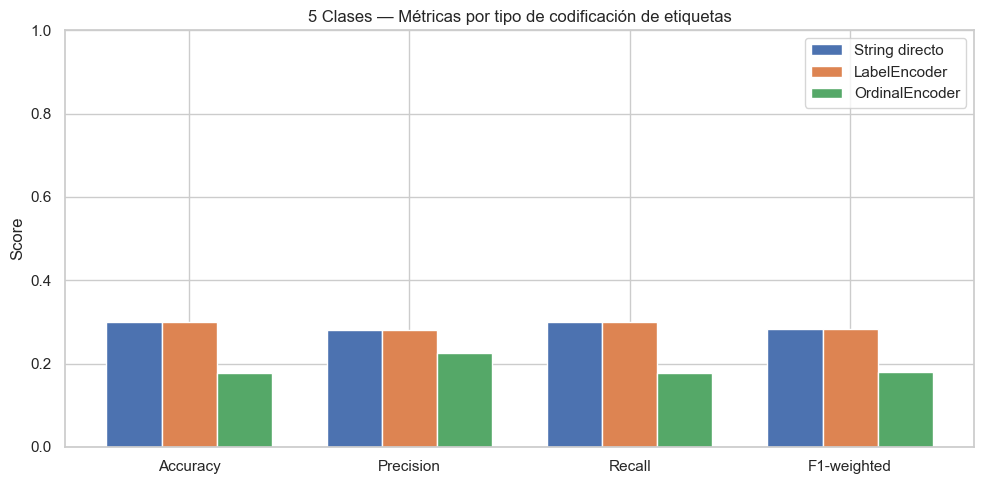

In [6]:
# Gráfica comparativa de codificaciones — 5 clases
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-weighted']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, row in df_cod5.iterrows():
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=row['Codificación'])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title('5 Clases — Métricas por tipo de codificación de etiquetas')
ax.legend()
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('eje1_codificacion_5clases.png', bbox_inches='tight')
plt.show()

### 1B — 3 Clases con diferentes codificaciones

In [7]:
bins3 = [-np.inf, -1, 5, np.inf]
labels3_str = ['Mujer mayor o igual', 'Hombre 0-5 años mayor', 'Hombre > 5 años mayor']
df_encoded['CAT3'] = pd.cut(df_encoded['DIFF_EDAD'], bins=bins3, labels=labels3_str)

orden_natural_3 = ['Mujer mayor o igual', 'Hombre 0-5 años mayor', 'Hombre > 5 años mayor']

y3_str = df_encoded['CAT3'].astype(str)

le3 = LabelEncoder()
y3_le = le3.fit_transform(y3_str)
print(f"LabelEncoder 3 clases — mapeo: {dict(zip(le3.classes_, le3.transform(le3.classes_)))}")

oe3 = OrdinalEncoder(categories=[orden_natural_3])
y3_ord = oe3.fit_transform(y3_str.values.reshape(-1, 1)).ravel().astype(int)
print(f"OrdinalEncoder 3 clases — orden natural preservado")

X3_tr, X3_te, y3str_tr, y3str_te = train_test_split(X, y3_str, test_size=0.2, random_state=42, stratify=y3_str)
_, _, y3le_tr, y3le_te   = train_test_split(X, pd.Series(y3_le),  test_size=0.2, random_state=42, stratify=y3_le)
_, _, y3ord_tr, y3ord_te = train_test_split(X, pd.Series(y3_ord), test_size=0.2, random_state=42, stratify=y3_ord)

r_str3, m_str3, _ = entrenar_y_evaluar(X3_tr, X3_te, y3str_tr, y3str_te, 'String directo')
r_le3,  m_le3,  _ = entrenar_y_evaluar(X3_tr, X3_te, y3le_tr,  y3le_te,  'LabelEncoder')
r_ord3, m_ord3, _ = entrenar_y_evaluar(X3_tr, X3_te, y3ord_tr, y3ord_te, 'OrdinalEncoder')

df_cod3 = pd.DataFrame([r_str3, r_le3, r_ord3])
print("\n=== 3 Clases — Comparación por codificación ===")
print(df_cod3.to_string(index=False))

LabelEncoder 3 clases — mapeo: {'Hombre 0-5 años mayor': 0, 'Hombre > 5 años mayor': 1, 'Mujer mayor o igual': 2}
OrdinalEncoder 3 clases — orden natural preservado

=== 3 Clases — Comparación por codificación ===
  Codificación  Accuracy  Precision   Recall  F1-weighted
String directo  0.344711   0.447476 0.344711     0.333796
  LabelEncoder  0.344711   0.447476 0.344711     0.333796
OrdinalEncoder  0.298080   0.394968 0.298080     0.300441


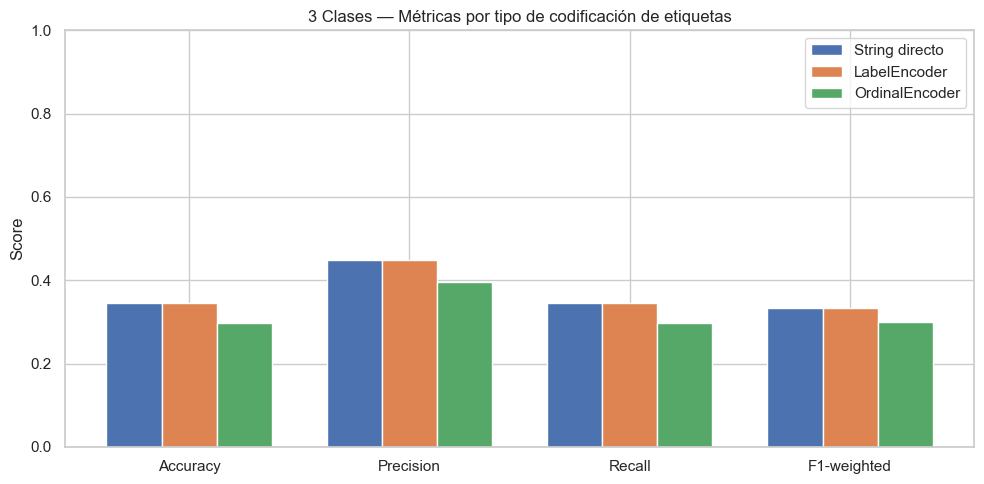

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, row in df_cod3.iterrows():
    ax.bar(x + i * width, [row[m] for m in metrics], width, label=row['Codificación'])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title('3 Clases — Métricas por tipo de codificación de etiquetas')
ax.legend()
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('eje1_codificacion_3clases.png', bbox_inches='tight')
plt.show()

---
## 🧪 EJE 2: Estrategias de Balanceo de Clases

### ¿Por qué importa?
En el bloque de 5 clases, la clase `2-3 años` tiene ~9% de los datos. Hay tres enfoques:

| Estrategia | Mecanismo | Efecto esperado |
|---|---|---|
| `class_weight='balanced'` | Penaliza más errores en clases minoritarias | Mejora recall en clases pequeñas |
| SMOTE | Genera ejemplos sintéticos de clases minoritarias | Balancea el dataset de entrenamiento |
| Random Undersampling | Reduce ejemplos de clases mayoritarias | Dataset más pequeño pero balanceado |
| Sin balanceo (baseline) | El modelo ve la distribución real | Puede ignorar clases pequeñas |

### 2A — Balanceo en 5 Clases

In [9]:
# Usar codificación OrdinalEncoder (orden explícito) como base para este eje
X5_tr, X5_te, y5ord_tr, y5ord_te = train_test_split(
    X, pd.Series(y5_ord), test_size=0.2, random_state=42, stratify=y5_ord
)

print("Distribución en train (antes de balanceo):")
print(pd.Series(y5ord_tr).value_counts().sort_index())

resultados_bal5 = []

# ---------- Variante 1: Sin balanceo ----------
rf_nobal = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_leaf=5,
                                   max_features='sqrt', n_jobs=-1, random_state=42)
rf_nobal.fit(X5_tr, y5ord_tr)
pred = rf_nobal.predict(X5_te)
resultados_bal5.append({
    'Estrategia': 'Sin balanceo',
    'Accuracy':    accuracy_score(y5ord_te, pred),
    'F1-weighted': f1_score(y5ord_te, pred, average='weighted', zero_division=0),
    'F1-macro':    f1_score(y5ord_te, pred, average='macro', zero_division=0),
})

# ---------- Variante 2: class_weight='balanced' ----------
rf_cw = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_leaf=5,
                                class_weight='balanced', max_features='sqrt',
                                n_jobs=-1, random_state=42)
rf_cw.fit(X5_tr, y5ord_tr)
pred = rf_cw.predict(X5_te)
resultados_bal5.append({
    'Estrategia': 'class_weight balanced',
    'Accuracy':    accuracy_score(y5ord_te, pred),
    'F1-weighted': f1_score(y5ord_te, pred, average='weighted', zero_division=0),
    'F1-macro':    f1_score(y5ord_te, pred, average='macro', zero_division=0),
})

# ---------- Variante 3: SMOTE ----------
if IMBLEARN_OK:
    smote = SMOTE(random_state=42)
    X5_sm, y5_sm = smote.fit_resample(X5_tr, y5ord_tr)
    print(f"\nTamaño train tras SMOTE: {X5_sm.shape[0]} filas")
    rf_smote = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_leaf=5,
                                       max_features='sqrt', n_jobs=-1, random_state=42)
    rf_smote.fit(X5_sm, y5_sm)
    pred = rf_smote.predict(X5_te)
    resultados_bal5.append({
        'Estrategia': 'SMOTE',
        'Accuracy':    accuracy_score(y5ord_te, pred),
        'F1-weighted': f1_score(y5ord_te, pred, average='weighted', zero_division=0),
        'F1-macro':    f1_score(y5ord_te, pred, average='macro', zero_division=0),
    })

    # ---------- Variante 4: Random Undersampling ----------
    rus = RandomUnderSampler(random_state=42)
    X5_us, y5_us = rus.fit_resample(X5_tr, y5ord_tr)
    print(f"Tamaño train tras Undersampling: {X5_us.shape[0]} filas")
    rf_under = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_leaf=5,
                                       max_features='sqrt', n_jobs=-1, random_state=42)
    rf_under.fit(X5_us, y5_us)
    pred = rf_under.predict(X5_te)
    resultados_bal5.append({
        'Estrategia': 'Undersampling',
        'Accuracy':    accuracy_score(y5ord_te, pred),
        'F1-weighted': f1_score(y5ord_te, pred, average='weighted', zero_division=0),
        'F1-macro':    f1_score(y5ord_te, pred, average='macro', zero_division=0),
    })

df_bal5 = pd.DataFrame(resultados_bal5)
print("\n=== 5 Clases — Comparación por estrategia de balanceo ===")
print(df_bal5.to_string(index=False))

Distribución en train (antes de balanceo):
0    187496
1    124986
2     56873
3     86926
4    145111
Name: count, dtype: int64

Tamaño train tras SMOTE: 937480 filas
Tamaño train tras Undersampling: 284365 filas

=== 5 Clases — Comparación por estrategia de balanceo ===
           Estrategia  Accuracy  F1-weighted  F1-macro
         Sin balanceo  0.332792     0.215519  0.150456
class_weight balanced  0.297714     0.279897  0.235531
                SMOTE  0.309167     0.273380  0.223291
        Undersampling  0.298286     0.276388  0.232056


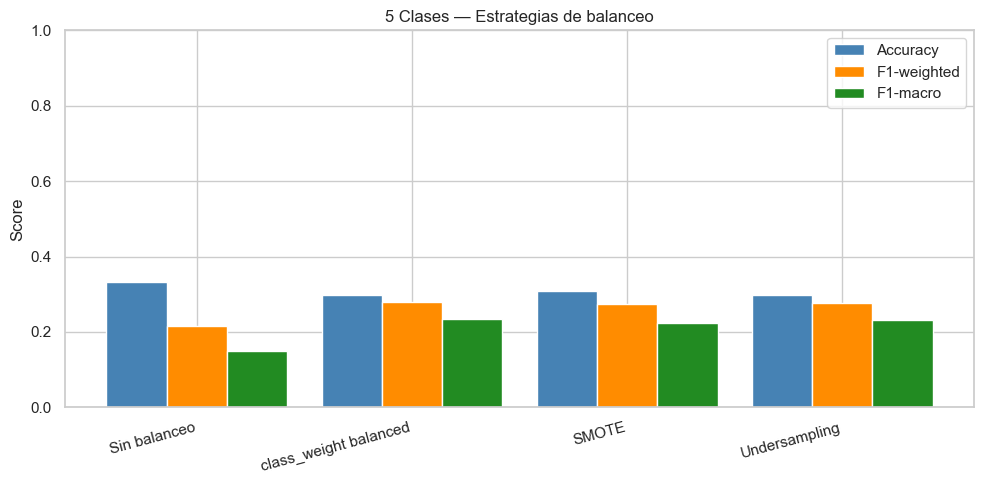

In [10]:
# Gráfica de balanceo — 5 clases
fig, ax = plt.subplots(figsize=(10, 5))
x_bal = np.arange(len(df_bal5))
w = 0.28
ax.bar(x_bal - w, df_bal5['Accuracy'],    w, label='Accuracy',    color='steelblue')
ax.bar(x_bal,     df_bal5['F1-weighted'], w, label='F1-weighted', color='darkorange')
ax.bar(x_bal + w, df_bal5['F1-macro'],    w, label='F1-macro',    color='forestgreen')
ax.set_xticks(x_bal)
ax.set_xticklabels(df_bal5['Estrategia'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_title('5 Clases — Estrategias de balanceo')
ax.legend()
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('eje2_balanceo_5clases.png', bbox_inches='tight')
plt.show()

# Nota: F1-macro es clave aquí — penaliza igual a todas las clases
# independientemente de su tamaño, por eso es más informativo que F1-weighted
# cuando hay desbalance.

### 2B — Balanceo en 3 Clases

In [11]:
X3_tr, X3_te, y3ord_tr, y3ord_te = train_test_split(
    X, pd.Series(y3_ord), test_size=0.2, random_state=42, stratify=y3_ord
)

print("Distribución en train (3 clases):")
print(pd.Series(y3ord_tr).value_counts().sort_index())

resultados_bal3 = []

for cw, label in [(None, 'Sin balanceo'), ('balanced', 'class_weight balanced')]:
    rf = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_leaf=5,
                                 class_weight=cw, max_features='sqrt',
                                 n_jobs=-1, random_state=42)
    rf.fit(X3_tr, y3ord_tr)
    pred = rf.predict(X3_te)
    resultados_bal3.append({
        'Estrategia': label,
        'Accuracy':    accuracy_score(y3ord_te, pred),
        'F1-weighted': f1_score(y3ord_te, pred, average='weighted', zero_division=0),
        'F1-macro':    f1_score(y3ord_te, pred, average='macro', zero_division=0),
    })

if IMBLEARN_OK:
    for sampler, label in [(SMOTE(random_state=42), 'SMOTE'),
                            (RandomUnderSampler(random_state=42), 'Undersampling')]:
        X_s, y_s = sampler.fit_resample(X3_tr, y3ord_tr)
        rf = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_leaf=5,
                                     max_features='sqrt', n_jobs=-1, random_state=42)
        rf.fit(X_s, y_s)
        pred = rf.predict(X3_te)
        resultados_bal3.append({
            'Estrategia': label,
            'Accuracy':    accuracy_score(y3ord_te, pred),
            'F1-weighted': f1_score(y3ord_te, pred, average='weighted', zero_division=0),
            'F1-macro':    f1_score(y3ord_te, pred, average='macro', zero_division=0),
        })

df_bal3 = pd.DataFrame(resultados_bal3)
print("\n=== 3 Clases — Comparación por estrategia de balanceo ===")
print(df_bal3.to_string(index=False))

Distribución en train (3 clases):
0    132851
1    323430
2    145111
Name: count, dtype: int64

=== 3 Clases — Comparación por estrategia de balanceo ===
           Estrategia  Accuracy  F1-weighted  F1-macro
         Sin balanceo  0.537802     0.376162  0.233147
class_weight balanced  0.348802     0.340104  0.349731
                SMOTE  0.374209     0.379882  0.368850
        Undersampling  0.336145     0.318257  0.336873


---
## 🧪 EJE 3: Bins Alternativos (Umbrales de las Clases)

### ¿Por qué importa?
La elección de los cortes es **arbitraria en la v1**. Si los bins no reflejan la distribución real de los datos, el modelo intenta aprender fronteras que no existen naturalmente. Se prueban:

- **Bins originales** (referencia)
- **Bins por cuartiles** — cortes en Q25, Q50, Q75 (basados en los datos)
- **Bins simétricos** — ±2, ±5 (intuitivo y balanceado)
- **Bins clínicos** — enfocados en diferencias culturalmente relevantes

In [12]:
q25, q50, q75 = np.percentile(df_encoded['DIFF_EDAD'], [25, 50, 75])
print(f"Percentiles DIFF_EDAD — Q25={q25:.1f}, Q50={q50:.1f}, Q75={q75:.1f}")
print(f"Media: {df_encoded['DIFF_EDAD'].mean():.1f} | Mediana: {df_encoded['DIFF_EDAD'].median():.1f}")

configs_bins = [
    {
        'nombre': 'Originales (v1)',
        'bins':   [-np.inf, 0, 2, 3, 5, np.inf],
        'labels': ['C1', 'C2', 'C3', 'C4', 'C5']
    },
    {
        'nombre': 'Por cuartiles',
        'bins':   [-np.inf, q25, q50, q75, np.inf],
        'labels': ['Q1', 'Q2', 'Q3', 'Q4']
    },
    {
        'nombre': 'Simétricos ±2 ±5',
        'bins':   [-np.inf, -5, -2, 2, 5, np.inf],
        'labels': ['< -5', '-5 a -2', '-2 a 2', '2 a 5', '> 5']
    },
    {
        'nombre': 'Clínicos (±1, ±3, ±7)',
        'bins':   [-np.inf, -3, 1, 7, np.inf],
        'labels': ['Mujer notablemente mayor', 'Similar', 'Hombre algo mayor', 'Hombre notablemente mayor']
    },
]

resultados_bins = []

for cfg in configs_bins:
    cat = pd.cut(df_encoded['DIFF_EDAD'], bins=cfg['bins'], labels=cfg['labels']).astype(str)
    cat = cat.dropna()
    X_cfg = X.loc[cat.index]

    le = LabelEncoder()
    y_enc = le.fit_transform(cat)

    Xtr, Xte, ytr, yte = train_test_split(X_cfg, y_enc, test_size=0.2,
                                           random_state=42, stratify=y_enc)
    rf = RandomForestClassifier(n_estimators=150, max_depth=10, min_samples_leaf=5,
                                 class_weight='balanced', max_features='sqrt',
                                 n_jobs=-1, random_state=42)
    rf.fit(Xtr, ytr)
    pred = rf.predict(Xte)

    resultados_bins.append({
        'Bins': cfg['nombre'],
        'N clases': len(cfg['labels']),
        'Accuracy':    accuracy_score(yte, pred),
        'F1-weighted': f1_score(yte, pred, average='weighted', zero_division=0),
        'F1-macro':    f1_score(yte, pred, average='macro', zero_division=0),
    })
    print(f"{cfg['nombre']}: Acc={accuracy_score(yte,pred):.3f}, F1-w={f1_score(yte,pred,average='weighted',zero_division=0):.3f}")

df_bins = pd.DataFrame(resultados_bins)
print("\n=== Comparación por definición de bins ===")
print(df_bins.to_string(index=False))

Percentiles DIFF_EDAD — Q25=0.0, Q50=2.0, Q75=5.0
Media: 3.0 | Mediana: 2.0
Originales (v1): Acc=0.298, F1-w=0.280
Por cuartiles: Acc=0.322, F1-w=0.304
Simétricos ±2 ±5: Acc=0.264, F1-w=0.269
Clínicos (±1, ±3, ±7): Acc=0.294, F1-w=0.290

=== Comparación por definición de bins ===
                 Bins  N clases  Accuracy  F1-weighted  F1-macro
      Originales (v1)         5  0.297714     0.279897  0.235531
        Por cuartiles         4  0.322204     0.303704  0.291825
     Simétricos ±2 ±5         5  0.263820     0.269410  0.232766
Clínicos (±1, ±3, ±7)         4  0.294462     0.290246  0.277368


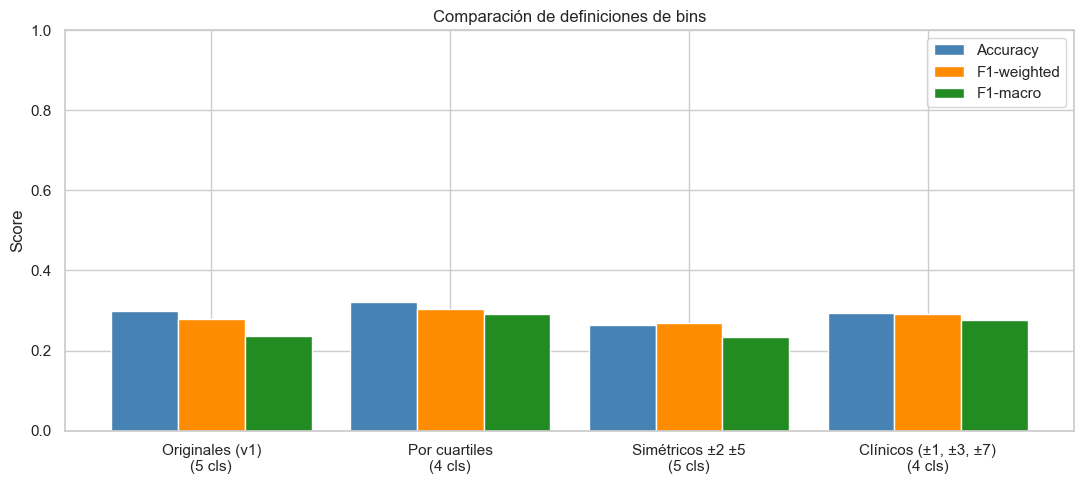

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
x_bins = np.arange(len(df_bins))
ax.bar(x_bins - w, df_bins['Accuracy'],    w, label='Accuracy',    color='steelblue')
ax.bar(x_bins,     df_bins['F1-weighted'], w, label='F1-weighted', color='darkorange')
ax.bar(x_bins + w, df_bins['F1-macro'],    w, label='F1-macro',    color='forestgreen')
ax.set_xticks(x_bins)
ax.set_xticklabels([f"{r['Bins']}\n({r['N clases']} cls)" for _, r in df_bins.iterrows()],
                   ha='center')
ax.set_ylim(0, 1)
ax.set_title('Comparación de definiciones de bins')
ax.legend()
ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('eje3_bins.png', bbox_inches='tight')
plt.show()

---
## 🧪 EJE 4: Comparación Explícita de Modelos dentro de cada Bloque

En la v1, los 3 configs de cada bloque se mostraban en una tabla de texto pero **sin gráfica comparativa**. Aquí se visualizan las métricas de las 3 configuraciones lado a lado para cada bloque, y luego se cruzan los mejores de 5 vs 3 clases.

In [14]:
# Reutilizar las codificaciones OrdinalEncoder + class_weight balanced para consistencia

configs_comparacion = [
    {'n': 50,  'depth': None, 'leaf': 1, 'oob': False, 'label': 'Baseline\n(50 árboles)'},
    {'n': 100, 'depth': 8,   'leaf': 1, 'oob': False, 'label': 'Intermedio\n(100, d=8)'},
    {'n': 150, 'depth': 10,  'leaf': 5, 'oob': True,  'label': 'Avanzado\n(150, d=10)'},
]

def correr_configs(X_tr, X_te, y_tr, y_te, configs, titulo):
    rows = []
    for cfg in configs:
        rf = RandomForestClassifier(
            n_estimators=cfg['n'], max_depth=cfg['depth'],
            min_samples_leaf=cfg['leaf'], oob_score=cfg['oob'],
            class_weight='balanced', max_features='sqrt',
            n_jobs=-1, random_state=42
        )
        rf.fit(X_tr, y_tr)
        pred = rf.predict(X_te)
        oob = rf.oob_score_ if cfg['oob'] else np.nan
        rows.append({
            'Config': cfg['label'],
            'Accuracy':    accuracy_score(y_te, pred),
            'F1-weighted': f1_score(y_te, pred, average='weighted', zero_division=0),
            'F1-macro':    f1_score(y_te, pred, average='macro',    zero_division=0),
            'OOB':         oob,
        })
    df_r = pd.DataFrame(rows)
    print(f"\n=== {titulo} ===")
    print(df_r.to_string(index=False))
    return df_r

X5_tr2, X5_te2, y5_tr2, y5_te2 = train_test_split(X, pd.Series(y5_ord), test_size=0.2,
                                                    random_state=42, stratify=y5_ord)
X3_tr2, X3_te2, y3_tr2, y3_te2 = train_test_split(X, pd.Series(y3_ord), test_size=0.2,
                                                    random_state=42, stratify=y3_ord)

df_comp5 = correr_configs(X5_tr2, X5_te2, y5_tr2, y5_te2, configs_comparacion, '5 Clases — 3 configuraciones')
df_comp3 = correr_configs(X3_tr2, X3_te2, y3_tr2, y3_te2, configs_comparacion, '3 Clases — 3 configuraciones')


=== 5 Clases — 3 configuraciones ===
                Config  Accuracy  F1-weighted  F1-macro     OOB
Baseline\n(50 árboles)  0.244451     0.247589  0.217754     NaN
Intermedio\n(100, d=8)  0.298206     0.278907  0.234671     NaN
 Avanzado\n(150, d=10)  0.297714     0.279897  0.235531 0.29669

=== 3 Clases — 3 configuraciones ===
                Config  Accuracy  F1-weighted  F1-macro      OOB
Baseline\n(50 árboles)  0.409940     0.411663  0.355081      NaN
Intermedio\n(100, d=8)  0.345217     0.335137  0.346132      NaN
 Avanzado\n(150, d=10)  0.348802     0.340104  0.349731 0.346563


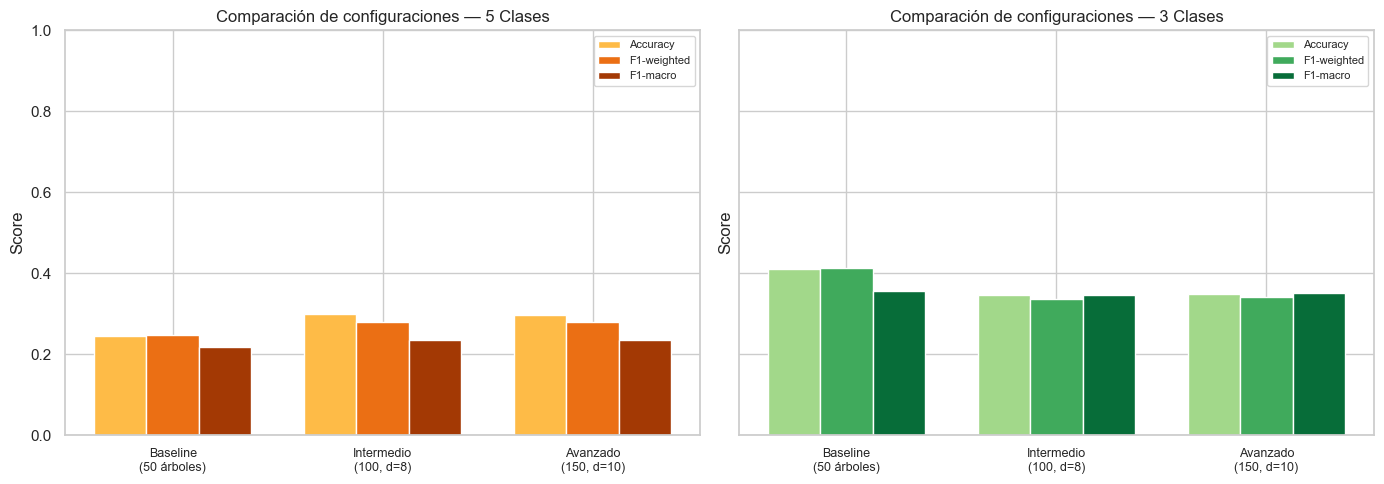

In [15]:
# Gráfica lado a lado: 5 clases vs 3 clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, df_c, titulo, color in [
    (axes[0], df_comp5, '5 Clases', 'YlOrBr'),
    (axes[1], df_comp3, '3 Clases', 'YlGn')
]:
    met = ['Accuracy', 'F1-weighted', 'F1-macro']
    x_c = np.arange(len(df_c))
    w_c = 0.25
    colors = plt.colormaps[color](np.linspace(0.4, 0.85, len(met)))
    for j, (m, col) in enumerate(zip(met, colors)):
        ax.bar(x_c + j*w_c, df_c[m], w_c, label=m, color=col)
    ax.set_xticks(x_c + w_c)
    ax.set_xticklabels(df_c['Config'], ha='center', fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Comparación de configuraciones — {titulo}')
    ax.legend(fontsize=8)
    ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig('eje4_configs_comparacion.png', bbox_inches='tight')
plt.show()

---
## 📊 RESUMEN GLOBAL — Comparación Cruzada de Todos los Experimentos

In [16]:
print("=" * 70)
print("RESUMEN GLOBAL — TODOS LOS EJES")
print("=" * 70)

resumen = []

# Eje 1: mejor codificación
best_cod5 = df_cod5.loc[df_cod5['F1-weighted'].idxmax()]
best_cod3 = df_cod3.loc[df_cod3['F1-weighted'].idxmax()]
resumen.append({'Eje': 'Codificación', 'Variante': f"5 cls — {best_cod5['Codificación']}",
                'F1-weighted': best_cod5['F1-weighted'], 'Accuracy': best_cod5['Accuracy']})
resumen.append({'Eje': 'Codificación', 'Variante': f"3 cls — {best_cod3['Codificación']}",
                'F1-weighted': best_cod3['F1-weighted'], 'Accuracy': best_cod3['Accuracy']})

# Eje 2: mejor balanceo
best_bal5 = df_bal5.loc[df_bal5['F1-weighted'].idxmax()]
best_bal3 = df_bal3.loc[df_bal3['F1-weighted'].idxmax()]
resumen.append({'Eje': 'Balanceo', 'Variante': f"5 cls — {best_bal5['Estrategia']}",
                'F1-weighted': best_bal5['F1-weighted'], 'Accuracy': best_bal5['Accuracy']})
resumen.append({'Eje': 'Balanceo', 'Variante': f"3 cls — {best_bal3['Estrategia']}",
                'F1-weighted': best_bal3['F1-weighted'], 'Accuracy': best_bal3['Accuracy']})

# Eje 3: mejor bins
best_bins = df_bins.loc[df_bins['F1-weighted'].idxmax()]
resumen.append({'Eje': 'Bins', 'Variante': best_bins['Bins'],
                'F1-weighted': best_bins['F1-weighted'], 'Accuracy': best_bins['Accuracy']})

# Eje 4: mejor config
best_cfg5 = df_comp5.loc[df_comp5['F1-weighted'].idxmax()]
best_cfg3 = df_comp3.loc[df_comp3['F1-weighted'].idxmax()]
resumen.append({'Eje': 'Config', 'Variante': f"5 cls — {best_cfg5['Config'].replace(chr(10), ' ')}",
                'F1-weighted': best_cfg5['F1-weighted'], 'Accuracy': best_cfg5['Accuracy']})
resumen.append({'Eje': 'Config', 'Variante': f"3 cls — {best_cfg3['Config'].replace(chr(10), ' ')}",
                'F1-weighted': best_cfg3['F1-weighted'], 'Accuracy': best_cfg3['Accuracy']})

df_resumen = pd.DataFrame(resumen)
print(df_resumen.to_string(index=False))

RESUMEN GLOBAL — TODOS LOS EJES
         Eje                      Variante  F1-weighted  Accuracy
Codificación        5 cls — String directo     0.282698  0.300647
Codificación        3 cls — String directo     0.333796  0.344711
    Balanceo 5 cls — class_weight balanced     0.279897  0.297714
    Balanceo                 3 cls — SMOTE     0.379882  0.374209
        Bins                 Por cuartiles     0.303704  0.322204
      Config  5 cls — Avanzado (150, d=10)     0.279897  0.297714
      Config 3 cls — Baseline (50 árboles)     0.411663  0.409940


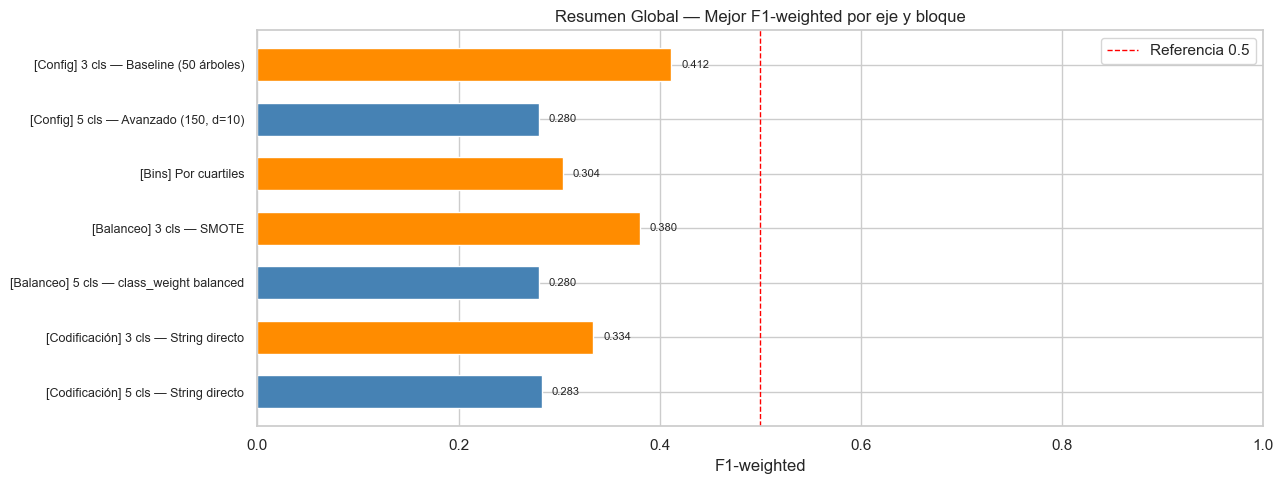


✅ Notebook v2 completado.
Archivos generados: eje1_codificacion_*.png, eje2_balanceo_*.png, eje3_bins.png,
                   eje4_configs_comparacion.png, resumen_global.png


In [17]:
# Gráfica de resumen global
fig, ax = plt.subplots(figsize=(13, 5))
y_pos = np.arange(len(df_resumen))
colors_bar = ['steelblue' if '5 cls' in v or 'Bins' in v else 'darkorange'
              for v in df_resumen['Variante']]

bars = ax.barh(y_pos, df_resumen['F1-weighted'], color=colors_bar, edgecolor='white', height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"[{r['Eje']}] {r['Variante']}" for _, r in df_resumen.iterrows()], fontsize=9)
ax.set_xlim(0, 1)
ax.set_xlabel('F1-weighted')
ax.set_title('Resumen Global — Mejor F1-weighted por eje y bloque')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='Referencia 0.5')
ax.legend()

for bar, val in zip(bars, df_resumen['F1-weighted']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('resumen_global.png', bbox_inches='tight')
plt.show()

print("\n✅ Notebook v2 completado.")
print("Archivos generados: eje1_codificacion_*.png, eje2_balanceo_*.png, eje3_bins.png,")
print("                   eje4_configs_comparacion.png, resumen_global.png")